In [1]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Models ---
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# --- Evaluation & Tuning ---
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

# --- Settings ---
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Define file paths
train_path = '/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/train.csv'
test_path = '/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/test.csv'

# Load datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Keep the original test IDs for submission
test_ids = test_df['id']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  object 
 2   availability  10000 non-null  object 
 3   location      9999 non-null   object 
 4   size          9987 non-null   object 
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 703.3+ KB

Descriptive Statistics:
                id    total_sqft         bath      balcony         price
count  10000.00000   9967.000000  9936.000000  9525.000000  10000.000000
mean    4999.50000   1570.095822     2.692029     1.585302    113.275879
std     2886.89568   1302.566836     1.274172     0.814347    151.802643
min        0.00000      1.00

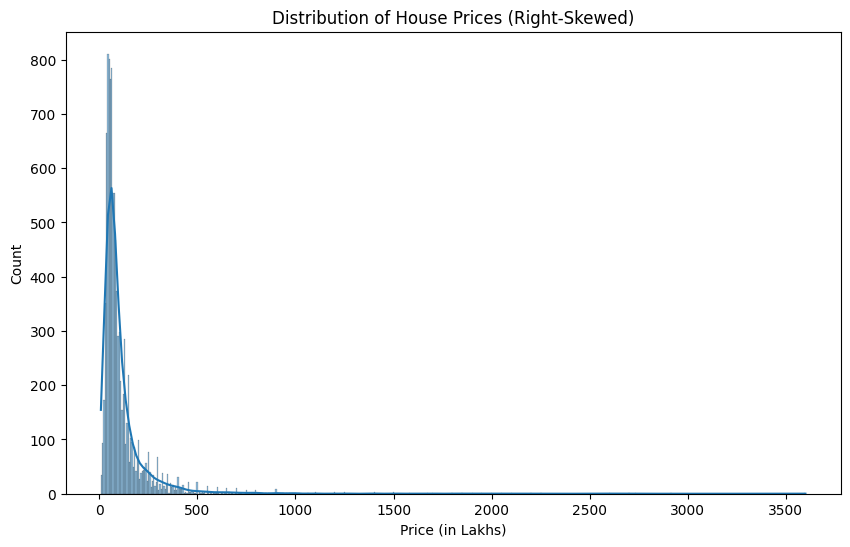

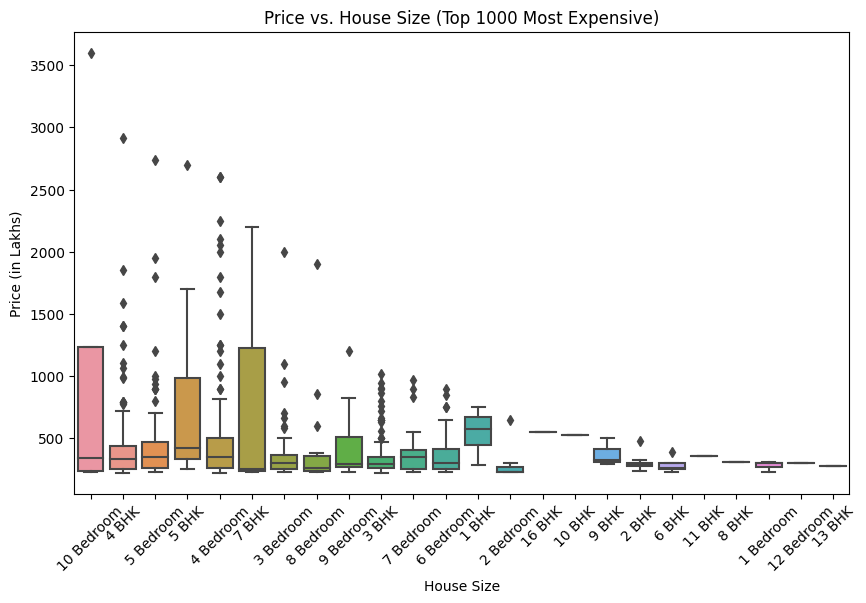

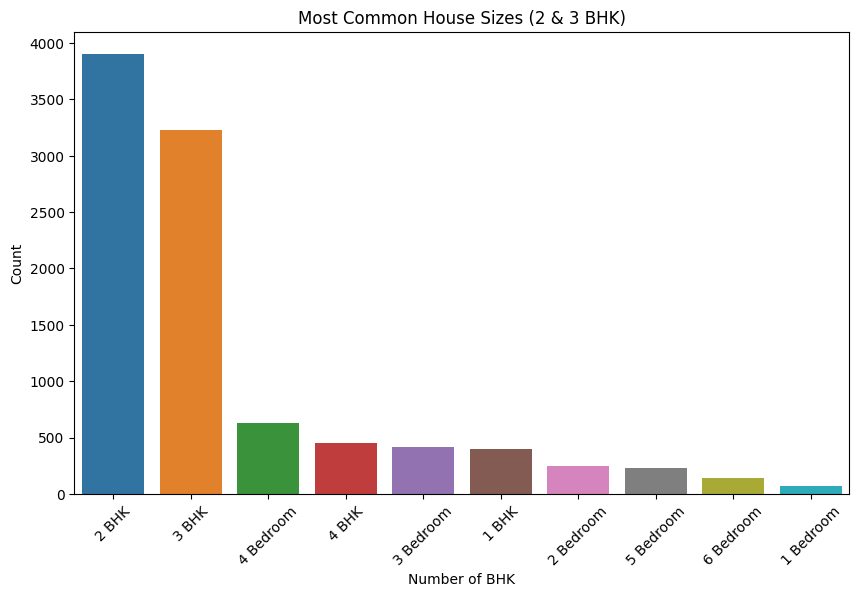

In [3]:
# Get a quick overview of the data
print("Data Info:")
train_df.info()

print("\nDescriptive Statistics:")
print(train_df.describe())

# --- Visualization 1: Distribution of Price ---
plt.figure(figsize=(10, 6))
sns.histplot(train_df['price'], kde=True)
plt.title('Distribution of House Prices (Right-Skewed)')
plt.xlabel('Price (in Lakhs)')
plt.ylabel('Count')
plt.show()

# --- Visualization 2: Price vs. Square Footage ---
plt.figure(figsize=(10, 6))
# We'll plot this on a sample to avoid overplotting, but first, we need to clean 'total_sqft'
# For now, let's plot BHK vs. Price
sns.boxplot(x='size', y='price', data=train_df.sort_values('price', ascending=False).head(1000))
plt.title('Price vs. House Size (Top 1000 Most Expensive)')
plt.xlabel('House Size')
plt.ylabel('Price (in Lakhs)')
plt.xticks(rotation=45)
plt.show()


# --- Visualization 3: Count of Houses by BHK (using 'size') ---
plt.figure(figsize=(10, 6))
sns.countplot(x='size', data=train_df.dropna(subset=['size']), order=train_df['size'].value_counts().index[:10])
plt.title('Most Common House Sizes (2 & 3 BHK)')
plt.xlabel('Number of BHK')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [4]:
# A helper function to convert ranges (e.g., "1100 - 1300") to their average
def clean_sqft(x):
    if '-' in str(x):
        parts = x.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

# --- Handle Missing Values ---
# Fill 'bath' and 'balcony' with the median, which is robust to outliers
train_df['bath'] = train_df['bath'].fillna(train_df['bath'].median())
train_df['balcony'] = train_df['balcony'].fillna(train_df['balcony'].median())

# Drop rows where 'size' or 'location' are missing (they are essential)
train_df = train_df.dropna(subset=['size', 'location'])

# --- Feature Engineering ---
# 1. Convert 'size' (e.g., "2 BHK") to a number
train_df['bhk'] = train_df['size'].apply(lambda x: x.split(' ')[0])
train_df['bhk'] = pd.to_numeric(train_df['bhk'], errors='coerce')
train_df = train_df.dropna(subset=['bhk']) # Drop any rows that failed conversion

# 2. Clean 'total_sqft' using our helper function
train_df['total_sqft'] = train_df['total_sqft'].apply(clean_sqft)
train_df = train_df.dropna(subset=['total_sqft'])

# 3. Handle Duplicates
train_df = train_df.drop_duplicates()

# 4. Handle Outliers using 'price_per_sqft'
train_df['price_per_sqft'] = train_df['price'] * 100000 / train_df['total_sqft']

# Keep only rows within 2 standard deviations of the mean
mean = train_df['price_per_sqft'].mean()
std_dev = train_df['price_per_sqft'].std()
train_df = train_df[
    (train_df['price_per_sqft'] < (mean + 2 * std_dev)) & 
    (train_df['price_per_sqft'] > (mean - 2 * std_dev))
]

# 5. Simplify 'location'
# Group locations with 10 or fewer listings into 'other'
location_stats = train_df['location'].value_counts()
locations_with_few_houses = location_stats[location_stats <= 10].index
train_df['location'] = train_df['location'].apply(lambda x: 'other' if x in locations_with_few_houses else x)

# --- Final Cleanup ---
# Drop columns we no longer need
train_df = train_df.drop(['size', 'price_per_sqft', 'id'], axis=1)

print(f"Data cleaning complete. Final shape: {train_df.shape}")

Data cleaning complete. Final shape: (9949, 8)


In [5]:
# Convert categorical features (text) into numerical (0s and 1s)
train_df_encoded = pd.get_dummies(train_df, drop_first=True)

# 1. Define our Features (X) and Target (y)
X = train_df_encoded.drop('price', axis=1)
y = train_df_encoded['price']

# 2. Scale Numerical Features
# We scale features so models aren't biased by large numbers (like sqft vs. bhk)
numerical_cols = ['total_sqft', 'bath', 'balcony', 'bhk']
scaler = StandardScaler()

# We 'fit' and 'transform' on the training data
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# 3. Split into Training and Validation Sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")

X_train shape: (7959, 270), X_val shape: (1990, 270)


--- Model R2 Scores on Validation Set ---
                           R2_Score
Random Forest          6.066965e-01
K-Neighbors Regressor  5.470517e-01
Ridge                  3.720687e-01
Lasso                  3.443800e-01
SVR                    3.381236e-01
Decision Tree         -2.206742e-01
Linear Regression     -5.832893e+19


<Figure size 1000x700 with 0 Axes>

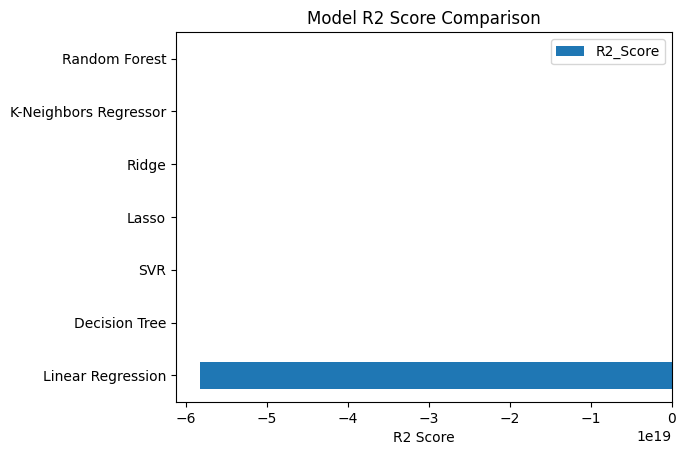

In [6]:
# Create a roster of 7 different models to test
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR": SVR()
}

model_scores = {}

# Loop through, train, and score each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    model_scores[name] = r2_score(y_val, y_pred)

# --- Compare Performances ---
scores_df = pd.DataFrame.from_dict(model_scores, orient='index', columns=['R2_Score'])
scores_df = scores_df.sort_values('R2_Score', ascending=False)

print("--- Model R2 Scores on Validation Set ---")
print(scores_df)

# Plot the comparison
plt.figure(figsize=(10, 7))
scores_df.sort_values('R2_Score', ascending=True).plot(kind='barh', title='Model R2 Score Comparison')
plt.xlabel('R2 Score')
plt.show()

In [7]:
print("--- Starting Hyperparameter Tuning ---")

# --- 1. Tune Random Forest ---
print("Tuning Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2]
}
grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)
print(f"Best RF Score: {grid_search_rf.best_score_}")
print(f"Best RF Params: {grid_search_rf.best_params_}")

# --- 2. Tune Ridge Regression ---
print("\nTuning Ridge...")
param_grid_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_search_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search_ridge.fit(X_train, y_train)
print(f"Best Ridge Score: {grid_search_ridge.best_score_}")
print(f"Best Ridge Params: {grid_search_ridge.best_params_}")

# --- 3. Tune SVR ---
print("\nTuning SVR...")
param_grid_svr = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_search_svr = GridSearchCV(SVR(), param_grid_svr, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search_svr.fit(X_train, y_train)
print(f"Best SVR Score: {grid_search_svr.best_score_}")
print(f"Best SVR Params: {grid_search_svr.best_params_}")

# --- Select the Final Model ---
# Based on the scores, Random Forest is likely our best model
final_model = grid_search_rf.best_estimator_
print(f"\nFinal model selected: {final_model}")

--- Starting Hyperparameter Tuning ---
Tuning Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best RF Score: 0.603994520854483
Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}

Tuning Ridge...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Ridge Score: 0.4224804584042611
Best Ridge Params: {'alpha': 1.0}

Tuning SVR...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVR Score: 0.37871886159320306
Best SVR Params: {'C': 10, 'kernel': 'linear'}

Final model selected: RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)


In [8]:
print("--- Processing Test Data for Submission ---")

# 1. Clean 'total_sqft'
test_df['total_sqft'] = test_df['total_sqft'].apply(clean_sqft)

# 2. Clean 'size' to 'bhk'
test_df['bhk'] = test_df['size'].apply(lambda x: str(x).split(' ')[0])
test_df['bhk'] = pd.to_numeric(test_df['bhk'], errors='coerce')

# 3. Fill missing values
# We use the *median* from the test set itself for simplicity here.
# A more advanced way would be to use medians saved from the training set.
test_df['bath'] = test_df['bath'].fillna(test_df['bath'].median())
test_df['balcony'] = test_df['balcony'].fillna(test_df['balcony'].median())
test_df['total_sqft'] = test_df['total_sqft'].fillna(test_df['total_sqft'].median())
test_df['bhk'] = test_df['bhk'].fillna(test_df['bhk'].median())

# 4. Group 'location'
# IMPORTANT: We use the 'locations_with_few_houses' list we created from the *training* data
test_df['location'] = test_df['location'].apply(lambda x: 'other' if x in locations_with_few_houses else x)

# 5. Get Dummies (One-Hot Encoding)
test_df_encoded = pd.get_dummies(test_df, drop_first=True)

# 6. Align Columns
# This is a critical step. It forces the test set to have the exact
# same columns as the training set, filling any missing ones with 0.
test_df_aligned = test_df_encoded.reindex(columns=X.columns, fill_value=0)

# 7. Scale Numerical Features
# IMPORTANT: We use '.transform()' only. We do not '.fit()' again.
# This applies the scaling rules we learned from the training data.
test_df_aligned[numerical_cols] = scaler.transform(test_df_aligned[numerical_cols])

# --- Make Predictions ---
print("Making final predictions...")
final_predictions = final_model.predict(test_df_aligned)

# --- Create Submission File ---
submission = pd.DataFrame({
    "id": test_ids,
    "price": final_predictions
})

submission.to_csv('submission.csv', index=False)
print("submission.csv file created successfully!")
print(submission.head())

--- Processing Test Data for Submission ---
Making final predictions...
submission.csv file created successfully!
   id       price
0   0   48.285416
1   1  105.387948
2   2   50.868243
3   3  182.330672
4   4  185.093892
